# Data Cleaning and Visualization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# Set visualization style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Load raw data
df = pd.read_csv("../data/stage1_loaded_data.csv")
print(f"Initial Dataset Shape: {df.shape}")
df.head()

Initial Dataset Shape: (70000, 12)


,review_id,user_name,review_text,rating,helpful_votes,app_version,review_date,developer_reply,developer_reply_date,app_name,review_length,hour
0,016bbd04-7f9c-4c2b-8f82-8d7cab4f424f,Sean Harris,"always happy with their service and goods,just...",5,0,32.4.0.100,2026-03-11 18:25:22,NaN,NaN,Amazon Shopping,97,18
1,7a6f39b1-5534-4eed-8100-1cdbedc5ea1e,Finn Fiechtner,pros and cons. 3 star review dead center. cons...,3,0,NaN,2026-03-11 18:15:01,NaN,NaN,Amazon Shopping,484,18
2,967d3ed1-6855-493d-8816-d7434a22180c,Bassam Yousre,the worst delivery service ever always not on ...,1,0,32.5.0.100,2026-03-11 18:08:16,NaN,NaN,Amazon Shopping,141,18
3,9767efd5-66d8-4dc8-a86f-2c2a26bd0ee4,SO SUPO,happy,4,0,32.5.0.100,2026-03-11 17:57:29,NaN,NaN,Amazon Shopping,5,17
4,26cf286d-c77c-4c64-ba92-dbb119a510fe,Steve Day,Says my phone is not compatible with tap to pa...,1,0,32.5.0.100,2026-03-11 16:45:46,NaN,NaN,Amazon Shopping,278,16


## 1. Missing Value Analysis
Identifying and handling null values to maintain data integrity.

Missing Values by Column:
user_name                   1
app_version             10837
developer_reply         41092
developer_reply_date    41092
dtype: int64


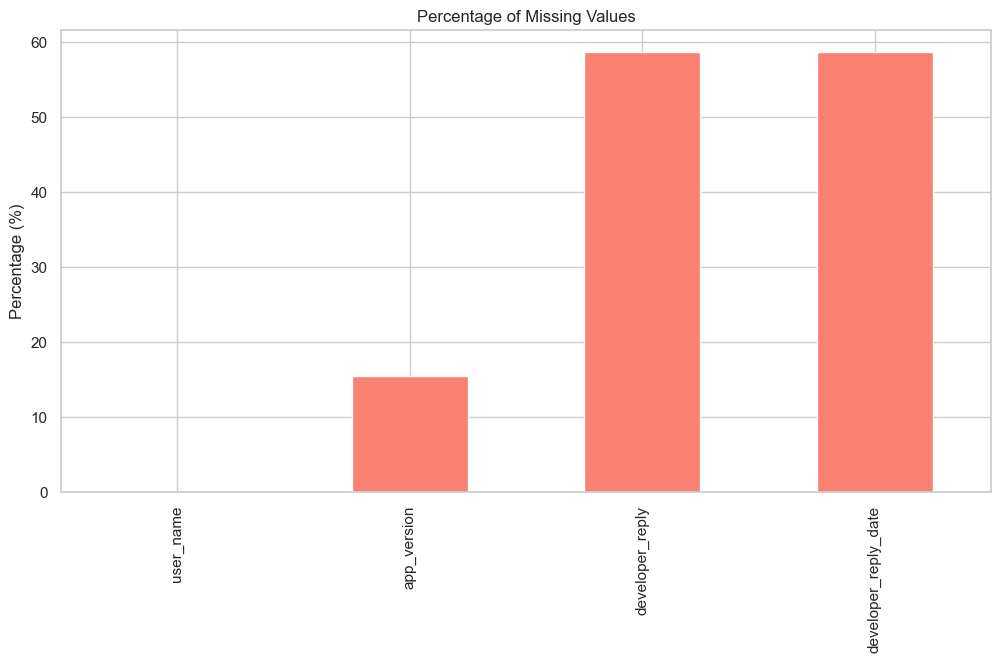

In [2]:
null_counts = df.isnull().sum()
print("Missing Values by Column:")
print(null_counts[null_counts > 0])

# Visualize Missing Values
if null_counts.sum() > 0:
    null_pct = (null_counts / len(df)) * 100
    null_pct[null_pct > 0].plot(kind='bar', color='salmon')
    plt.title("Percentage of Missing Values")
    plt.ylabel("Percentage (%)")
    plt.show()

In [3]:
# Handle missing values
df['user_name'] = df['user_name'].fillna("Anonymous")
df['review_text'] = df['review_text'].fillna("")

# Drop columns with too many missing values or irrelevant for detection
if 'developer_reply_date' in df.columns:
    df = df.drop(columns=['developer_reply_date'])

print(f"Dataset Shape after Null Handling: {df.shape}")

Dataset Shape after Null Handling: (70000, 11)


## 2. Duplicate Detection
Duplicate reviews are a common sign of spam/bot activity in fake review detection.

In [4]:
duplicates = df.duplicated(subset=['review_text', 'user_name']).sum()
print(f"Found {duplicates} potential duplicate reviews.")

# Remove exact duplicates while keeping the first occurrence
df = df.drop_duplicates(subset=['review_text', 'user_name'], keep='first')
print(f"Dataset Shape after Duplicate Removal: {df.shape}")

Found 263 potential duplicate reviews.
Dataset Shape after Duplicate Removal: (69737, 11)


## 3. Text Normalization and Cleaning
Preparing text for analysis and stripping unnecessary characters.

In [5]:
def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower() # Lowercase
    text = re.sub(r'\s+', ' ', text).strip() # Multi-space to single space
    return text

df['cleaned_review'] = df['review_text'].apply(clean_text)

# Drop reviews that became empty after cleaning
df = df[df['cleaned_review'] != ""]
print(f"Final Clean Dataset Shape: {df.shape}")

Final Clean Dataset Shape: (69737, 12)


## 4. Feature Engineering for Analysis
Adding columns that help us visualize the data distribution.

In [6]:
df['review_len'] = df['cleaned_review'].apply(len)
df['word_count'] = df['cleaned_review'].apply(lambda x: len(x.split()))
df['review_date'] = pd.to_datetime(df['review_date'])

df[['review_len', 'word_count']].describe()

,review_len,word_count
count,69737.000000,69737.000000
mean,71.276941,13.049529
std,115.496559,21.037970
min,1.000000,1.000000
25%,7.000000,1.000000
50%,19.000000,3.000000
75%,74.000000,13.000000
max,500.000000,116.000000


## 5. Visualizations: Confirming Data Health
These plots show the distribution of ratings and content, helping us verify that the data is ready for detection models.

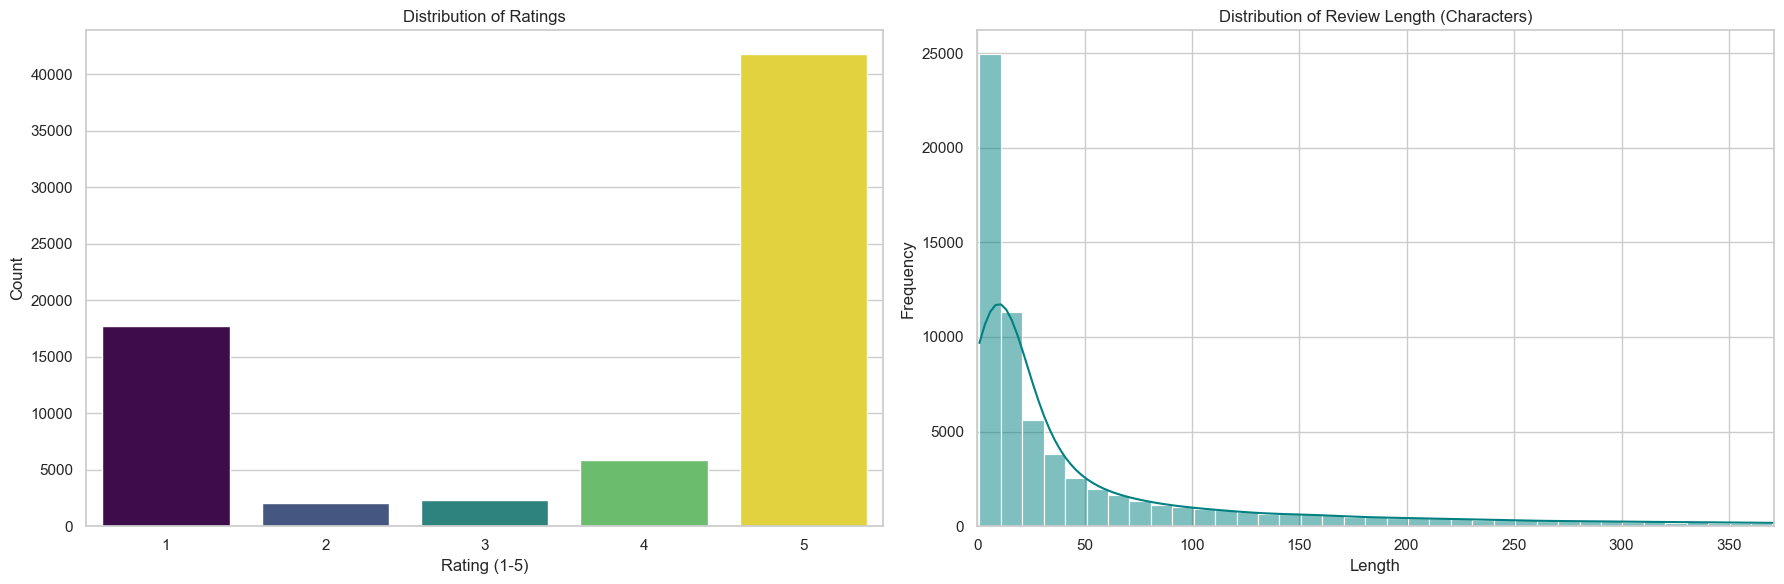

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 1. Rating Distribution
sns.countplot(x='rating', data=df, ax=ax1, hue='rating', palette='viridis', legend=False)
ax1.set_title("Distribution of Ratings")
ax1.set_xlabel("Rating (1-5)")
ax1.set_ylabel("Count")

# 2. Review Length Distribution
sns.histplot(df['review_len'], bins=50, kde=True, ax=ax2, color='teal')
ax2.set_title("Distribution of Review Length (Characters)")
ax2.set_xlabel("Length")
ax2.set_ylabel("Frequency")
ax2.set_xlim(0, df['review_len'].quantile(0.95)) # Zoom in on the bulk of reviews

plt.tight_layout()
plt.show()

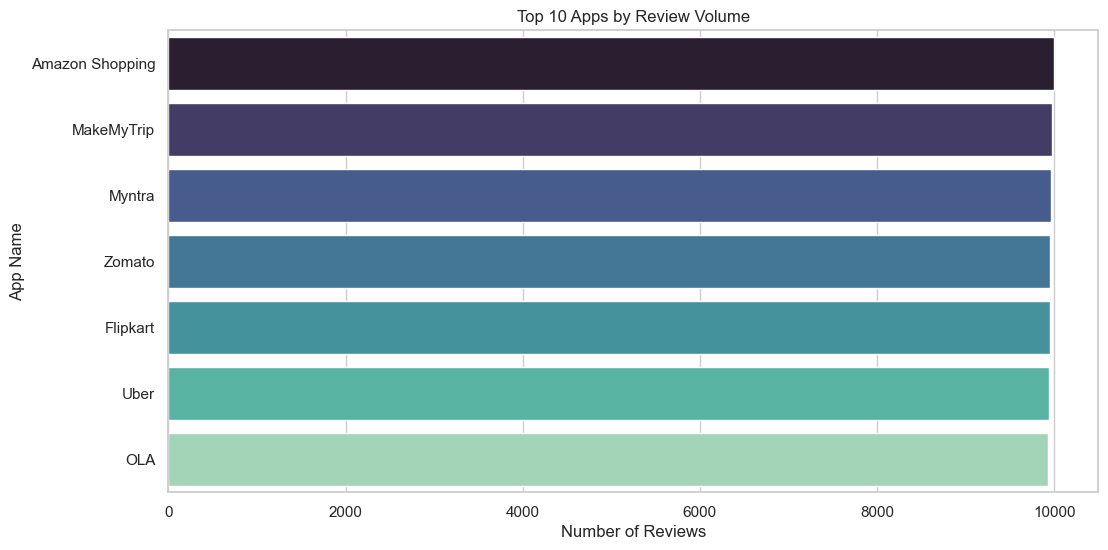

In [8]:
# 3. Top Apps by Review Volume
top_apps = df['app_name'].value_counts().head(10)
sns.barplot(y=top_apps.index, x=top_apps.values, hue=top_apps.index, palette='mako', legend=False)
plt.title("Top 10 Apps by Review Volume")
plt.xlabel("Number of Reviews")
plt.ylabel("App Name")
plt.show()

## 6. Saving Cleaned Data
Exporting the processed dataset for stage 3.

In [9]:
df.to_csv("../data/stage2_cleaned_data.csv", index=False)
print("Stage 2 Cleaning Complete. Data saved to 'data/stage2_cleaned_data.csv'")

Stage 2 Cleaning Complete. Data saved to 'data/stage2_cleaned_data.csv'
